<a href="https://colab.research.google.com/github/kipruto45/kipruto45/blob/main/Sentiment_Analysis_Twitter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display: flex; width: 100%; justify-content: space-between;">
    <div style = "width: 100%;">
        <h1 style="font-family: verdana; font-weight: bold;">Sentiment Analysis - Twitter</h1>
        <p style="color: #159364; font-family: cursive;">Natural Language Processing - NLP</p>
    </div>
    <div style="text-align: right;">
        <img style="border-radius: 15px;" src="https://storage.googleapis.com/kaggle-datasets-images/1520310/2510249/62d9f449c80ece3e48827afd505f39de/dataset-cover.jpeg?t=2021-08-09-02-12-59" alt="Image Description" width="250" height="250">
    </div>
</div>


## **Importing libraries**

In [1]:
import spacy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [15]:
df = pd.read_csv('/content/drive/MyDrive/Data sets/twitter_training.csv')
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


## **Explanation Data**

In [16]:
df.shape

(74681, 4)

In [17]:
df.columns


Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [19]:
df.isna().sum()

,0
2401,0
Borderlands,0
Positive,0
"im getting on borderlands and i will murder you all ,",686


In [20]:
df.duplicated().sum()

np.int64(2700)

## **Exploratory Data Analysis-(EDA)**

### **Sentiment Column**

In [21]:
df['Positive'].value_counts()

,count
Positive,
Negative,22542
Positive,20831
Neutral,18318
Irrelevant,12990


<ipython-input-22-e4ad005b6d59>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data = df, x = 'Positive', palette = 'Set2')


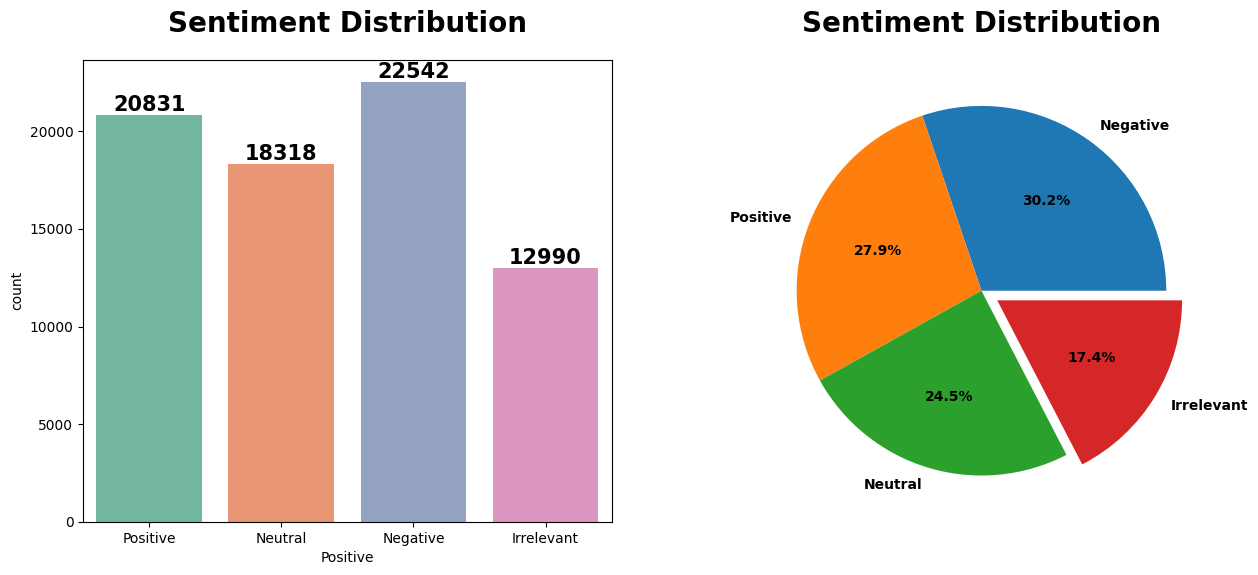

In [22]:
plt.figure(figsize = (15, 6))
plt.subplot(1,2,1)
ax = sns.countplot(data = df, x = 'Positive', palette = 'Set2')
for container in ax.containers:
    ax.bar_label(container, fontweight = 'black', size = 15)
plt.title("Sentiment Distribution", fontweight = 'black', size = 20, pad = 20)


plt.subplot(1,2,2)
plt.pie(df['Positive'].value_counts(), autopct = '%1.1f%%', labels = df['Positive'].value_counts().index, explode = [0,0,0,0.1],colors=sns.set_palette("Set2"), textprops={"fontweight":"black"})
plt.title("Sentiment Distribution", fontweight = 'black', size = 20, pad = 20)

plt.show()

### **Borderlands Column**

In [23]:
df['Borderlands'].value_counts()

,count
Borderlands,
Microsoft,2400
MaddenNFL,2400
TomClancysRainbowSix,2400
LeagueOfLegends,2394
CallOfDuty,2394
Verizon,2382
CallOfDutyBlackopsColdWar,2376
ApexLegends,2376
Facebook,2370


<ipython-input-24-28f1a8afe133>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = df['Borderlands'].value_counts().values, y = df['Borderlands'].value_counts().index, palette = 'viridis')


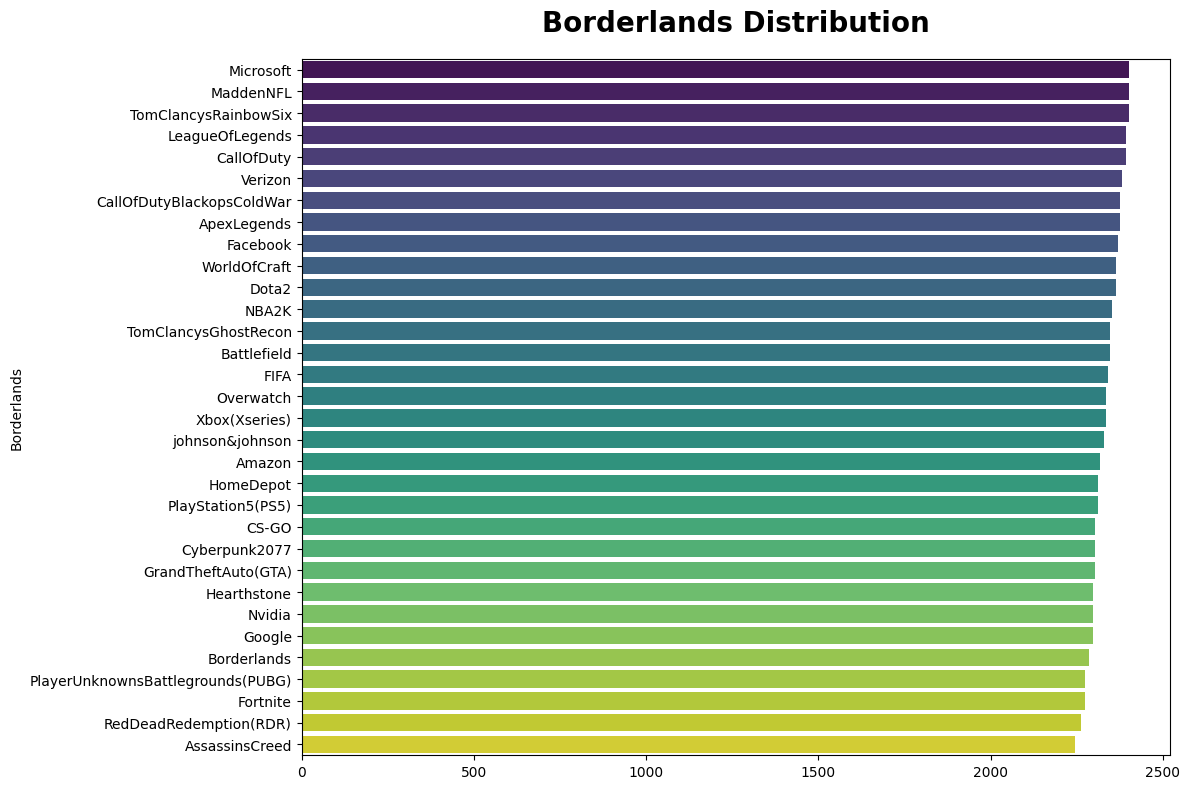

In [24]:
plt.figure(figsize = (12, 8))
sns.barplot(x = df['Borderlands'].value_counts().values, y = df['Borderlands'].value_counts().index, palette = 'viridis')
plt.title("Borderlands Distribution", fontweight = 'black', size = 20, pad = 20)

plt.tight_layout()
plt.show()

## **Data Preprocessing**

#### **Dealing With NULL Values**

In [27]:
df.dropna(inplace = True)

In [28]:
df.isna().sum()

,0
2401,0
Borderlands,0
Positive,0
"im getting on borderlands and i will murder you all ,",0


In [29]:
nlp = spacy.load('en_core_web_sm')

In [30]:
def preprocessing(text):
    doc = nlp(text)
    cleaned_tokens = []

    for token in doc:
        if token.is_stop or token.is_punct:
            continue

        else:
            cleaned_tokens.append(token.lemma_)

    return " ".join(cleaned_tokens)

In [31]:
df['cleaned_text'] = df['im getting on borderlands and i will murder you all ,'].apply(preprocessing)

In [32]:
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,",cleaned_text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,come border kill
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,m get borderland kill
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,m come borderland murder
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,m get borderland 2 murder
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,m get borderland murder


In [33]:
df['Combined_Text'] = df['cleaned_text'] + ' ' + df['Borderlands']

#### **Data Encoding**

In [34]:
encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['Positive'])

In [35]:
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,",cleaned_text,Combined_Text,label
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,come border kill,come border kill Borderlands,3
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,m get borderland kill,m get borderland kill Borderlands,3
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,m come borderland murder,m come borderland murder Borderlands,3
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,m get borderland 2 murder,m get borderland 2 murder Borderlands,3
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,m get borderland murder,m get borderland murder Borderlands,3


#### **Splitting Data**

In [37]:
X = df['Combined_Text']
y = df['label']


**Text Vectorizer**

In [39]:
tfidf = TfidfVectorizer()

X_vectorized = tfidf.fit_transform(X)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size = 0.2, random_state = 42)

In [41]:
X_train.shape

(59196, 28045)

In [42]:
y_train.shape

(59196,)

## **Train Model**

#### **Logistic Regression**

In [43]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [44]:
lr.score(X_train, y_train)

0.8412054868572201

In [45]:
y_pred = lr.predict(X_test)

In [46]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7749847962700183

<Axes: >

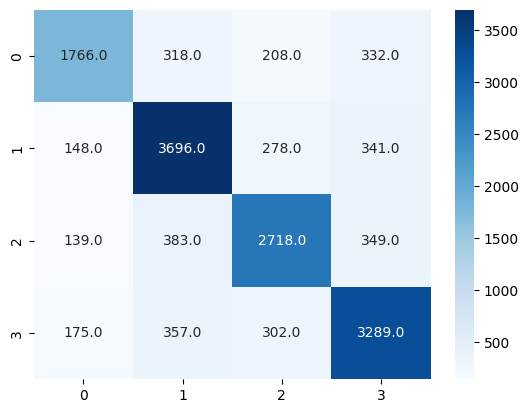

In [47]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True,fmt ='0.1f', cmap = 'Blues')

In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.67      0.73      2624
           1       0.78      0.83      0.80      4463
           2       0.78      0.76      0.77      3589
           3       0.76      0.80      0.78      4123

    accuracy                           0.77     14799
   macro avg       0.78      0.76      0.77     14799
weighted avg       0.78      0.77      0.77     14799



#### **Random Forest**

In [49]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

RandomForestClassifier()

In [50]:
rf.score(X_train, y_train)

0.981654165822015

In [51]:
y_pred = rf.predict(X_test)

In [52]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.940604094871275

<Axes: >

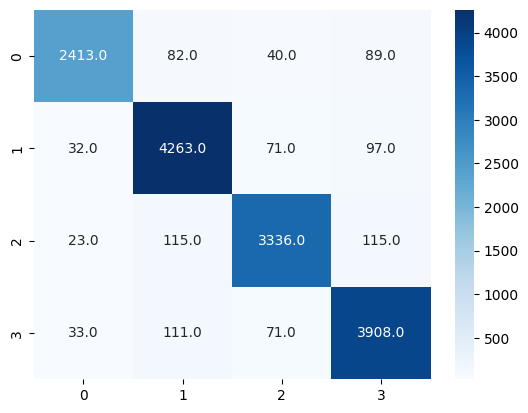

In [53]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True,fmt ='0.1f', cmap = 'Blues')

In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      2624
           1       0.93      0.96      0.94      4463
           2       0.95      0.93      0.94      3589
           3       0.93      0.95      0.94      4123

    accuracy                           0.94     14799
   macro avg       0.94      0.94      0.94     14799
weighted avg       0.94      0.94      0.94     14799

